In [60]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import glob
import json

### plotting functions

In [33]:
plt.rcParams['figure.dpi'] = 200

In [2]:
brbg = LinearSegmentedColormap.from_list('brbg', matplotlib.colormaps["BrBG"](np.arange(0, 1.1, .1)), N = 11)
pugy = LinearSegmentedColormap.from_list('pugy', np.concatenate([matplotlib.colormaps["RdGy_r"](np.arange(0.2, 0.5, .04)), 
                matplotlib.colormaps["PiYG_r"](np.arange(0.5, 0.85, .04))]), N = 10)

brbl = LinearSegmentedColormap.from_list('brbl', np.concatenate([matplotlib.colormaps["BrBG"](np.arange(0, 0.6, .1)), 
                matplotlib.colormaps["RdBu"](np.arange(0.5, 1.1, .1))]), N = 11)

bupu = LinearSegmentedColormap.from_list('bupu', matplotlib.colormaps["BuPu"](np.arange(0, 1.1, .1)), N = 10)
oranges = LinearSegmentedColormap.from_list('oranges', matplotlib.colormaps["Oranges"](np.arange(0, 1.1, .1)), N = 9)
reds = LinearSegmentedColormap.from_list('reds', matplotlib.colormaps["Reds"](np.arange(0, 1.1, .1)), N = 11)

In [3]:
from statsmodels.distributions.empirical_distribution import ECDF

In [4]:
def ecdf_func(cmip, obs):
    if np.isnan(cmip).all():
        return(np.nan)
    return (ECDF(cmip)(obs))

def ecdf_xr(cmip, obs):       
    return xr.apply_ufunc(ecdf_func, cmip, obs, 
                          input_core_dims = (["model_variant"], []), 
                          dask = "allowed", 
                          vectorize = True, ## required when function can only take 1D array
                         )

In [5]:
def plot_map(dat, lons, lats, ax, CMAP = None, VMIN = None, VMAX = None, na_col = "white", 
            label = None, legend = True):
    """ """
    if CMAP is None: 
        CMAP = "viridis"
    
    if na_col is not None:
        ax.set_facecolor(na_col)
    else: 
        ax.set_facecolor(plt.get_cmap(CMAP)(0))
    
    if VMIN is not None:
        p = ax.pcolormesh(lons, lats, dat, vmin = VMIN, vmax = VMAX, transform = ccrs.PlateCarree(), 
                          cmap = CMAP)
    else: 
        p = ax.pcolormesh(lons, lats, dat, transform = ccrs.PlateCarree(), cmap = CMAP)
    
    ax.add_feature(cfeature.LAND.with_scale('110m'), facecolor = 'white')
    ax.add_feature(cfeature.COASTLINE.with_scale('110m'), linewidth = 0.5)   
    if (label is not None) and (legend): 
        cb = plt.colorbar(p, ax = ax, shrink = 0.7, pad = 0.05, location = "bottom")
        cb.set_label(label=label,size = 16)
    elif legend: 
        plt.colorbar(p, ax = ax, shrink = 0.7, location = "bottom")

    return(p)

## Figure 1

In [8]:
start = 1979
end = 2020

In [9]:
dir = "../mnt_processed_data/"

In [61]:
model_var_dict = json.load(open(dir+"model_var_dict.json"))

#### read in data

In [27]:
cpc_trend = xr.open_dataset(dir+"cpc_trends/cpc_rx1day_"+str(start)+"-"+str(end)+"_5x5_trend.nc")
cpc_stat = xr.open_dataset(dir+"cpc_stats/cpc_rx1day_"+str(start)+"-"+str(end)+"_5x5_stats.nc")
cpc_trend_percent = (cpc_trend.sel(predictions = "coeff").value*10)/cpc_stat.mu*100

In [26]:
gpcc_trend = xr.open_dataset(dir+"gpcc_trends/gpcc_mon_"+str(start)+"-"+str(end)+"_5x5_p095_trend.nc")
gpcc_stat = xr.open_dataset(dir+"gpcc_stats/gpcc_mon_"+str(start)+"-"+str(end)+"_5x5_stats.nc")
gpcc_trend_percent = (gpcc_trend.sel(predictions = "coeff").value*10)/gpcc_stat.p95*100

In [75]:
cmip_files = sorted(glob.glob(dir+"cmip_trends/pr_rx1day_*5x5_"+str(start)+"-"+str(end)+"_trend.nc"))
cmip_day_trends = []
for f in cmip_files:
    x = xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]})

    cmip_day_trends.append(x)

cmip_day_trends = xr.concat(cmip_day_trends, dim = "model_variant")

In [76]:
files = sorted(glob.glob(dir+"cmip_stats/pr_rx1day_*_5x5_"+str(start)+"-"+str(end)+"_stats.nc"))
cmip_day_stat = []
for f in files:
    x = xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]})
    try:
        x = x.drop_vars("type")
    except:
        pass
    cmip_day_stat.append(x)
cmip_day_stat = xr.concat(cmip_day_stat, dim = "model_variant")

In [77]:
cmip_day_trend_percent = (cmip_day_trends.sel(predictions = "coeff").value*10)/cmip_day_stat.mu*100

In [80]:
cmip_files = sorted(glob.glob(dir+"cmip_trends/pr_mon_*5x5_"+str(start)+"-"+str(end)+"_p095_trend.nc"))
cmip_mon_trends = []
for f in cmip_files:
    x = xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]})
    try:
        x = x.drop_vars("type")
    except:
        pass
    cmip_mon_trends.append(x)

cmip_mon_trends = xr.concat(cmip_mon_trends, dim = "model_variant")

files = sorted(glob.glob(dir+"cmip_stats/pr_mon_*_5x5_"+str(start)+"-"+str(end)+"_stats.nc"))
cmip_mon_stat = []
for f in files:
    x = xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]})
    try:
        x = x.drop_vars("type")
    except:
        pass
    cmip_mon_stat.append(x)
cmip_mon_stat = xr.concat(cmip_mon_stat, dim = "model_variant")

cmip_mon_trend_percent = (cmip_mon_trends.sel(predictions = "coeff").value*10)/cmip_mon_stat.p95*100

#### figure

In [138]:
cmip_files = sorted(glob.glob(dir+"cmip_trends/pr_rx1day_*5x5_"+str(start)+"-"+str(end)+"_trend.nc"))

In [139]:
cmip_files

['../mnt_processed_data/cmip_trends/pr_rx1day_ACCESS-CM2_historical_ssp585_r10i1p1f1_5x5_1979-2020_trend.nc',
 '../mnt_processed_data/cmip_trends/pr_rx1day_ACCESS-CM2_historical_ssp585_r1i1p1f1_5x5_1979-2020_trend.nc',
 '../mnt_processed_data/cmip_trends/pr_rx1day_ACCESS-CM2_historical_ssp585_r2i1p1f1_5x5_1979-2020_trend.nc',
 '../mnt_processed_data/cmip_trends/pr_rx1day_ACCESS-CM2_historical_ssp585_r3i1p1f1_5x5_1979-2020_trend.nc',
 '../mnt_processed_data/cmip_trends/pr_rx1day_ACCESS-CM2_historical_ssp585_r4i1p1f1_5x5_1979-2020_trend.nc',
 '../mnt_processed_data/cmip_trends/pr_rx1day_ACCESS-CM2_historical_ssp585_r5i1p1f1_5x5_1979-2020_trend.nc',
 '../mnt_processed_data/cmip_trends/pr_rx1day_ACCESS-CM2_historical_ssp585_r6i1p1f1_5x5_1979-2020_trend.nc',
 '../mnt_processed_data/cmip_trends/pr_rx1day_ACCESS-CM2_historical_ssp585_r7i1p1f1_5x5_1979-2020_trend.nc',
 '../mnt_processed_data/cmip_trends/pr_rx1day_ACCESS-CM2_historical_ssp585_r8i1p1f1_5x5_1979-2020_trend.nc',
 '../mnt_processed

In [130]:
[m in cmip_day_trend_percent.model_variant for m in model_var_dict["cmip_day_onevar"]]

[True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 False,
 True,
 True,
 True,
 False,
 False,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True]

In [136]:
cmip_day_trend_percent

<xarray.DataArray (model_variant: 329, lat: 36, lon: 72)> Size: 7MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lat            (lat) float64 288B -87.5 -82.5 -77.5 -72.5 ... 77.5 82.5 87.5
  * lon            (lon) float64 576B 2.5 7.5 12.5 17.5 ... 347.5 352.5 357.5
    predictions    <U9 36B 'coeff'
  * model_variant  (model_variant) <U25 33kB 'ACCESS-CM2_r10i1p1f1' ... 'UKES...

In [131]:
model_var_dict["cmip_day_onevar"][12]

'EC-Earth3-CC_r1i1p1f1'

In [134]:
cmip_day_trend_percent.sel(model_variant = "EC-Earth3-CC_r1i1p1f1")

KeyError: "not all values found in index 'model_variant'. Try setting the `method` keyword argument (example: method='nearest')."

In [119]:
cmip_day_trend_percent

<xarray.DataArray (model_variant: 329, lat: 36, lon: 72)> Size: 7MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lat            (lat) float64 288B -87.5 -82.5 -77.5 -72.5 ... 77.5 82.5 87.5
  * lon            (lon) float64 576B 2.5 7.5 12.5 17.5 ... 347.5 352.5 357.5
    predictions    <U9 36B 'coeff'
  * model_variant  (model_variant) <U25 33kB 'ACCESS-CM2_r10i1p1f1' ... 'UKES...

In [118]:
cmip_day_trend_percent.sel(model_variant = model_var_dict["cmip_day_onevar"])

KeyError: "not all values found in index 'model_variant'"

KeyError: "not all values found in index 'model_variant'"

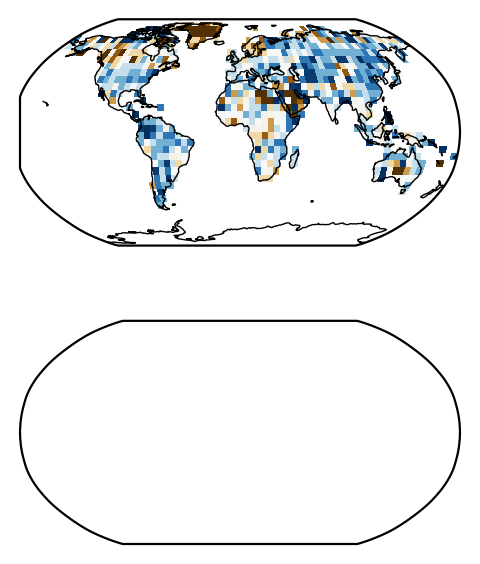

In [114]:
h_tot = 6.3
h = 1.5/h_tot
w_tot = 5
w = 2.2/w_tot

fig = plt.figure(figsize = (w_tot, h_tot))

ax = fig.add_axes([.04, h*3+0.05, w, h], projection = ccrs.Robinson())
plot_map(cpc_trend_percent, 
             cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)
ax = fig.add_axes([.04, h*2+0.05, w, h], projection = ccrs.Robinson())
plot_map(cmip_day_trend_percent.sel(model_variant = model_var_dict["cmip_day_onevar"]).mean(dim = "model_variant"), 
         cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)

ax = fig.add_axes([.04, h+0.05, w, h], projection = ccrs.Robinson())
ax = fig.add_axes([.04, 0.05, w, h], projection = ccrs.Robinson())

ax = fig.add_axes([.07+w, h*3+0.05, w, h], projection = ccrs.Robinson())
plot_map(gpcc_trend_percent, 
             gpcc_trend.lon, gpcc_trend.lat, ax, legend = False, 
             CMAP = brbl, VMIN = vmin, VMAX = vmax)
ax = fig.add_axes([.07+w, h*2+0.05, w, h], projection = ccrs.Robinson())
ax = fig.add_axes([.07+w, h+0.05, w, h], projection = ccrs.Robinson())
ax = fig.add_axes([.07+w, 0.05, w, h], projection = ccrs.Robinson())


plt.savefig("../figures/fig1.pdf")

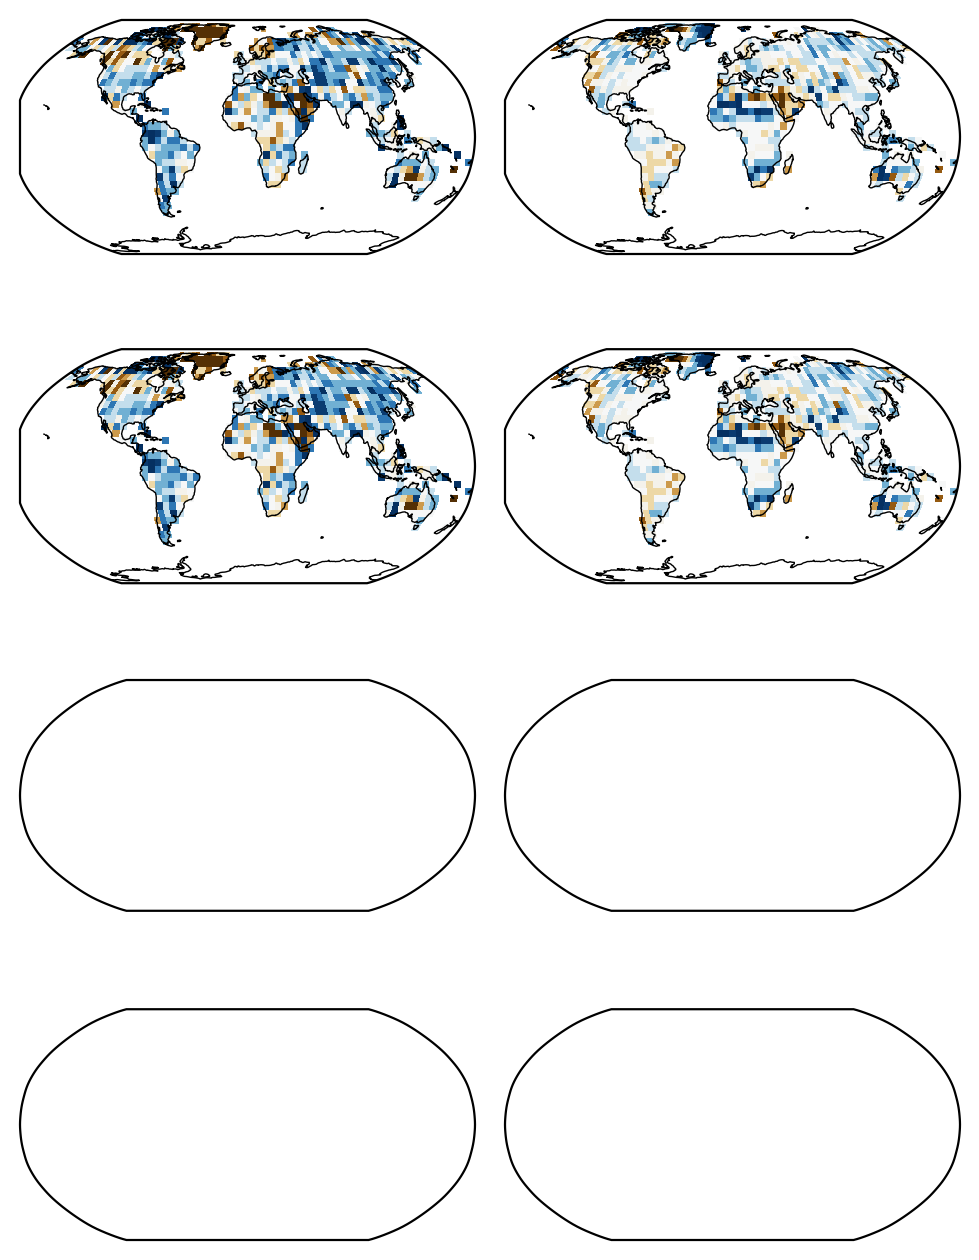

In [81]:
fig, axes = plt.subplots(4, 2, figsize = (4.7, 6.7), subplot_kw={"projection": ccrs.Robinson()})

vmin = -15
vmax = 15

ax = fig.add_axes
p = plot_map(cpc_trend_percent, 
             cpc_trend.lon, cpc_trend.lat, axes[0,0], legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)
p = plot_map(gpcc_trend_percent, 
             gpcc_trend.lon, gpcc_trend.lat, axes[0,1], legend = False, 
             CMAP = brbl, VMIN = vmin, VMAX = vmax)

p = plot_map(cpc_trend_percent, 
             cpc_trend.lon, gpcc_trend.lat, axes[1,0], legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)
p = plot_map(gpcc_trend_percent, 
             gpcc_trend.lon, gpcc_trend.lat, axes[1,1], legend = False, 
             CMAP = brbl, VMIN = vmin, VMAX = vmax)


plt.tight_layout()
plt.savefig("../figures/fig1.pdf")

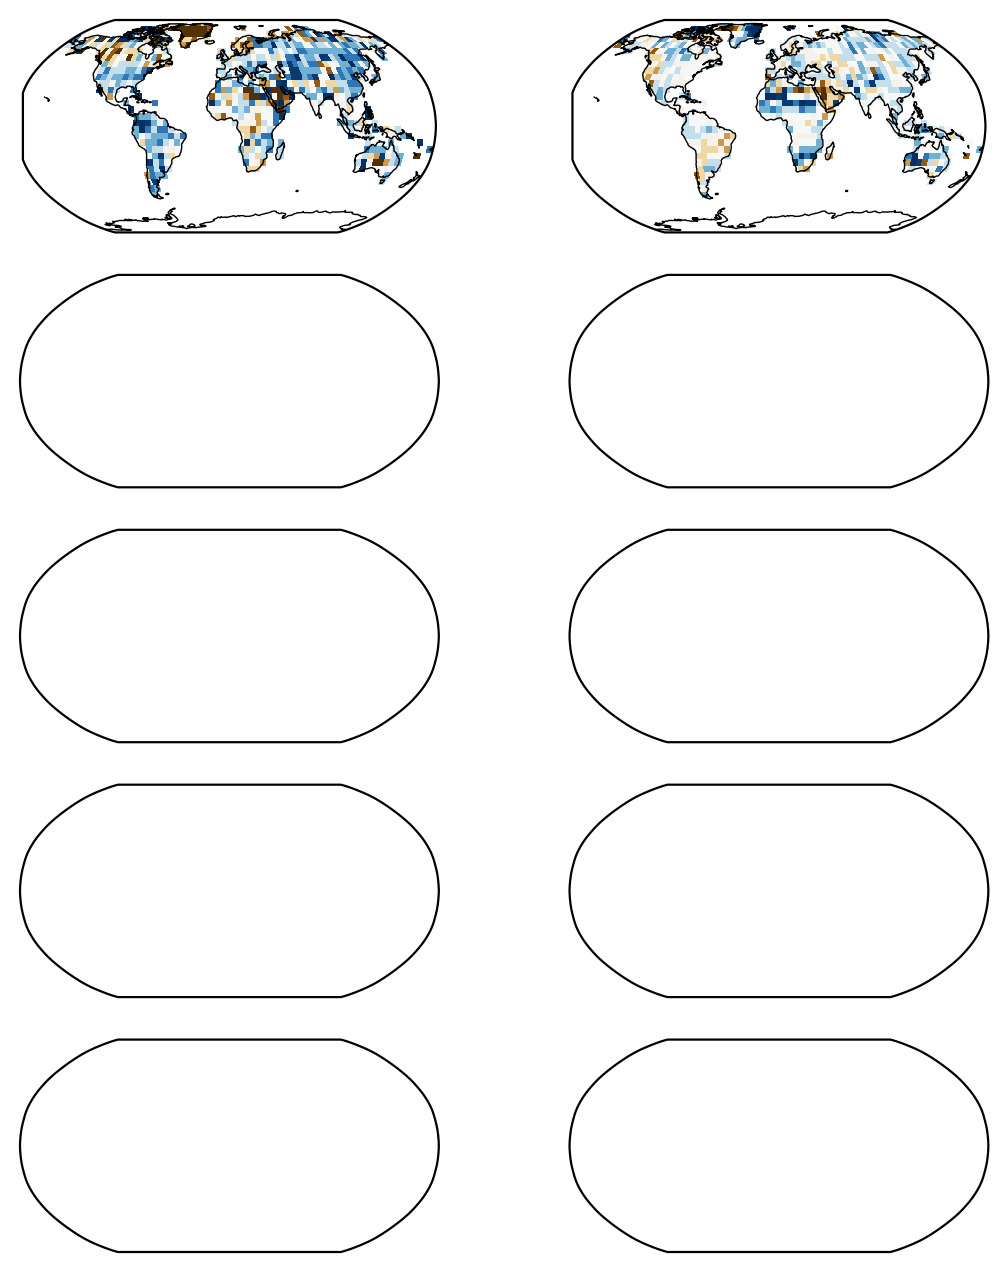

In [64]:
fig, axes = plt.subplots(5, 2, figsize = (6.5, 8), subplot_kw={"projection": ccrs.Robinson()})

vmin = -15
vmax = 15

p = plot_map(cpc_trend_percent, 
             cpc_trend.lon, gpcc_trend.lat, axes[0,0], legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)

p = plot_map(gpcc_trend_percent, 
             gpcc_trend.lon, gpcc_trend.lat, axes[0,1], legend = False, 
             CMAP = brbl, VMIN = vmin, VMAX = vmax)


plt.savefig("../figures/fig1.pdf")


In [13]:
## find cmip simulations with necessary criteria, read in data
cmip_files = sorted(glob.glob("../processed_data/cmip_trends/pr_mon_*5x5_"+str(start)+"-"+str(end)+"_p095_trend.nc"))
cmip_trends = []
for f in cmip_files:
    x = xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]})
    cmip_trends.append(x)

#cmip_trends = xr.concat(cmip_trends, dim = "model_variant")

In [8]:
gpcp_trend = xr.open_dataset(dir+"gpcp_trends/gpcp_mon_"+str(start)+"-"+str(end)+"_5x5_p095_trend.nc")
gpcp_stat = xr.open_dataset(dir+"gpcp_stats/gpcp_mon_"+str(start)+"-"+str(end)+"_5x5_stats.nc")
gpcp_trend_percent = (gpcp_trend.sel(predictions = "coeff").value*40)/gpcp_stat.p95*100

In [9]:
mswep_mon_trend = xr.open_dataset(dir+"mswep_trends/mswep_mon_"+str(start)+"-"+str(end)+"_5x5_p095_trend.nc")
mswep_mon_stat = xr.open_dataset(dir+"mswep_stats/mswep_mon_"+str(start)+"-"+str(end)+"_5x5_stats.nc")
mswep_mon_trend_percent = (mswep_mon_trend.sel(predictions = "coeff").value*40)/mswep_mon_stat.p95*100

In [16]:
for i in range(1, len(cmip_trends)):
    xr.concat(cmip_trends[0:i], dim = "model_variant")

MergeError: conflicting values for variable 'type' on objects to be combined. You can skip this check by specifying compat='override'.

In [17]:
i

64

In [22]:
cmip_trends[i]

<xarray.Dataset> Size: 88kB
Dimensions:        (lon: 72, lat: 30, predictions: 5)
Coordinates:
    type           |S255 255B ...
  * lon            (lon) float64 576B 2.5 7.5 12.5 17.5 ... 347.5 352.5 357.5
  * lat            (lat) float64 240B -57.5 -52.5 -47.5 -42.5 ... 77.5 82.5 87.5
  * predictions    (predictions) <U13 260B 'coeff' ... 'coeff_ci_high'
    model_variant  <U19 76B 'CNRM-CM6-1_r1i1p1f2'
Data variables:
    value          (lat, lon, predictions) float64 86kB ...

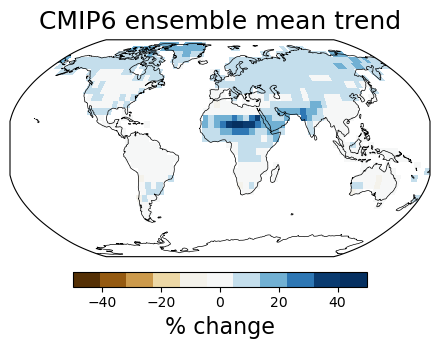

In [19]:
fig, ax = plt.subplots(1, 1, figsize = (4.5, 3.6), subplot_kw={"projection": ccrs.Robinson()})

ax.set_title("CMIP6 ensemble mean trend", size = 18, y = 1.05, transform = ax.transAxes)
ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
p = plot_map(cmip_trend_percent.sel(model_variant = onevar_model_keys).mean(dim = "model_variant"), 
             cmip_trends.lon, cmip_trends.lat, ax = ax, label = "% change", 
             CMAP = brbl, VMIN = -50, VMAX = 50)
plt.tight_layout()

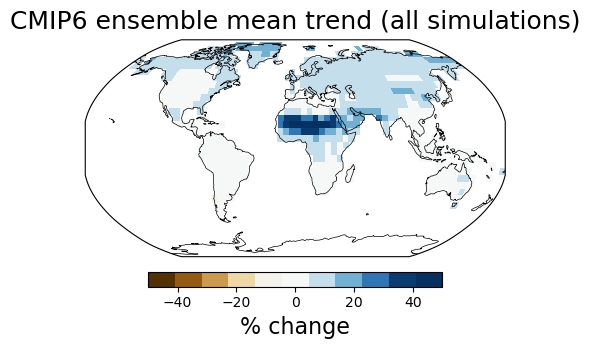

In [20]:
fig, ax = plt.subplots(1, 1, figsize = (4.5, 3.6), subplot_kw={"projection": ccrs.Robinson()})

ax.set_title("CMIP6 ensemble mean trend (all simulations)", size = 18, y = 1.05, transform = ax.transAxes)
ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
p = plot_map(cmip_trend_percent.mean(dim = "model_variant"), 
             cmip_trends.lon, cmip_trends.lat, ax = ax, label = "% change", 
             CMAP = brbl, VMIN = -50, VMAX = 50)
plt.tight_layout()

In [21]:
ecdf_mon = ecdf_xr(cmip_trend_percent.sel(model_variant = onevar_model_keys), gpcp_trend_percent.sel(lat = slice(-58.75, 88.75)))

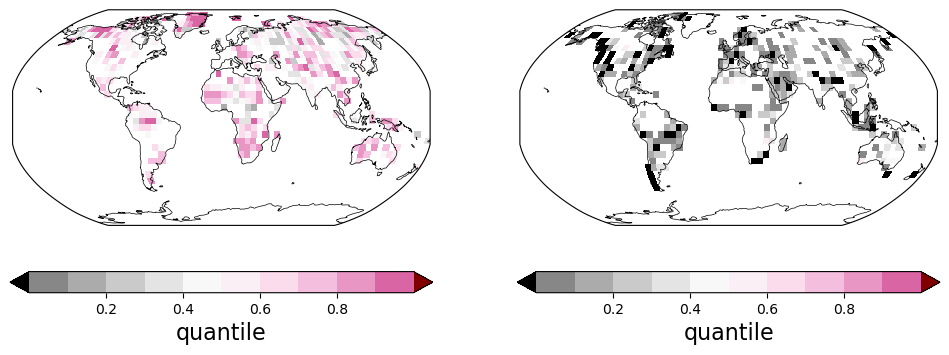

In [22]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4), subplot_kw={"projection": ccrs.Robinson()})

for ax in axes:
    ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())

p = plot_map(xr.where(gpcp_trend_percent.sel(lat = slice(-58.75, 88.75)) > 0, ecdf_mon, np.nan), 
             cmip_trends.lon, cmip_trends.lat, ax = axes[0], label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False)
p.cmap.set_over("maroon")
p.cmap.set_under('black')
cb = plt.colorbar(p, location = "bottom", extend = "both")
cb.set_label(label="quantile",size = 16)

p = plot_map(xr.where(gpcp_trend_percent.sel(lat = slice(-58.75, 88.75)) < 0, ecdf_mon, np.nan),
                      cmip_trends.lon, cmip_trends.lat, ax = axes[1], label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False)
p.cmap.set_over("maroon")
p.cmap.set_under('black')
cb = plt.colorbar(p, location = "bottom", extend = "both")
cb.set_label(label="quantile",size = 16)

### time series plots

In [51]:
def calc_ecdf(start, ens = "sub"):
    print(start)
    end = 2020
    trend = xr.open_dataset("../processed_data/gpcc_trends/gpcc_mon_"+str(start)+"-"+str(end)+"_5x5_p095_trend.nc")
    stat = xr.open_dataset("../processed_data/gpcc_stats/gpcc_mon_"+str(start)+"-"+str(end)+"_5x5_stats.nc")
    trend_sd = (trend.sel(predictions = "coeff").value*(end-start+1))/stat.p95*100

    files = sorted(glob.glob("../processed_data/cmip_trends/pr_mon_*5x5_"+str(start)+"-"+str(end)+"_p095_trend.nc"))
    mtrend = []
    for f in files:
        x = xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]})
        try:
            x = x.drop_vars("type")
        except:
            y = 0
        mtrend.append(x)
    mtrend = xr.concat(mtrend, dim = "model_variant")

    files = sorted(glob.glob("../processed_data/cmip_stats/pr_mon_*_5x5_"+str(start)+"-"+str(start+39)+"_stats.nc"))
    mstat = []
    for f in files:
        x = xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]})
        try:
            x = x.drop_vars("type")
        except:
            y = 0
        mstat.append(x)
    mstat = xr.concat(mstat, dim = "model_variant", coords = "minimal")

    mtrend_sd = (mtrend.sel(predictions = "coeff").value*(end-start+1))/mstat.p95*100

    if ens == "full":
        ecdf_dat = ecdf_xr(mtrend_sd, 
                           trend_sd.sel(lat = slice(-58.75, 88.75)))
    elif ens == "sub": 
        ecdf_dat = ecdf_xr(mtrend_sd.sel(model_variant = onevar_model_keys), 
                           trend_sd.sel(lat = slice(-58.75, 88.75)))

    ## number of positive trends (in each time period)
    summary_dat = pd.DataFrame({"start_year": [start], 
                                "pos_trends": (trend_sd > 0).sum().values,
                                "neg_trends": (trend_sd < 0).sum().values, 
                                "ecdf_1": ((trend_sd > 0) & (ecdf_dat == 1)).sum().values,
                                "ecdf_97.5": ((trend_sd > 0) & (ecdf_dat >= 0.975)).sum().values,
                                "ecdf_0": ((trend_sd < 0) & (ecdf_dat == 0)).sum().values,
                                "ecdf_025": ((trend_sd < 0) & (ecdf_dat <= 0.025)).sum().values, 
                                "ens_mean_pos": (mtrend_sd > 0).sum(dim = ["lat", "lon"]).mean(dim = "model_variant").values,
                                "ens_max_pos": (mtrend_sd > 0).sum(dim = ["lat", "lon"]).max(dim = "model_variant").values,
                                "ens_min_pos":(mtrend_sd > 0).sum(dim = ["lat", "lon"]).min(dim = "model_variant").values})

    return(ecdf_dat, summary_dat)

In [52]:
ecdf_alldates = []
summary_dat = []
for s in np.arange(1930, 1985, 5):
    a, b = calc_ecdf(s, ens = "sub")
    ecdf_alldates.append(a.assign_coords({"start_year": s}))
    summary_dat.append(b)

ecdf_alldates = xr.concat(ecdf_alldates, dim = "start_year", coords = "minimal")
summary_dat = pd.concat(summary_dat)

1930
1935
1940
1945
1950
1955
1960
1965
1970
1975
1980


In [53]:
summary_dat

,start_year,pos_trends,neg_trends,ecdf_1,ecdf_97.5,ecdf_0,ecdf_025,ens_mean_pos,ens_max_pos,ens_min_pos
0,1930,470,243,0,0,64,100,251.943953,602,0
0,1935,444,269,0,0,81,124,254.879056,604,0
0,1940,431,282,0,0,80,116,257.575221,611,0
0,1945,434,279,0,0,89,128,261.283186,604,0
0,1950,414,299,0,0,102,140,265.554572,607,0
0,1955,399,314,0,0,94,139,269.501475,614,0
0,1960,390,323,0,0,70,105,488.427729,611,0
0,1965,402,311,0,0,68,100,490.528024,603,0
0,1970,410,303,0,0,59,97,493.894602,601,0
0,1975,392,321,0,0,61,100,487.843188,591,0


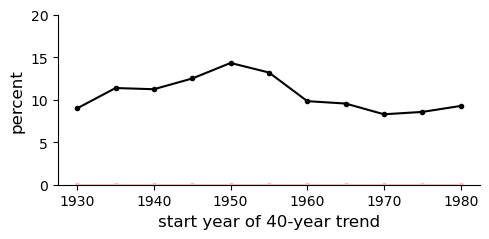

In [54]:
fig, ax = plt.subplots(figsize = (5, 2.5))

ax.plot(summary_dat.start_year, 
        (summary_dat.ecdf_0)/713*100, 
        marker = ".", color = "black")
ax.plot(summary_dat.start_year, 
        (summary_dat.ecdf_1)/713*100, 
        marker = ".", color = "pink")

ax.set(ylim = (0,20))
ax.set_ylabel("percent", fontsize = 12)
ax.set_xlabel("start year of 40-year trend", fontsize = 12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

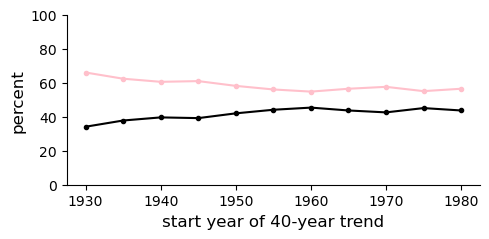

In [55]:
fig, ax = plt.subplots(figsize = (5, 2.5))

ax.plot(summary_dat.start_year, 
        (summary_dat.pos_trends)/713*100, 
        marker = ".", color = "pink")
ax.plot(summary_dat.start_year, 
        (summary_dat.neg_trends)/713*100, 
        marker = ".", color = "black")

ax.set(ylim = (0,100))
ax.set_ylabel("percent", fontsize = 12)
ax.set_xlabel("start year of 40-year trend", fontsize = 12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()